In [3]:
import numpy as np
import pandas as pd

In [6]:
df = pd.read_csv('smsspamcollection.tsv', sep='\t')
df.head()

,label,message,length,punct
0,ham,"Go until jurong point, crazy.. Available only ...",111,9
1,ham,Ok lar... Joking wif u oni...,29,6
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,6
3,ham,U dun say so early hor... U c already then say...,49,6
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,2


In [7]:
df.shape

(5572, 4)

In [8]:
df.isnull().sum()

,0
label,0
message,0
length,0
punct,0


In [9]:
df['label'].value_counts()

,count
label,
ham,4825
spam,747


In [17]:
df['punct'].value_counts()

,count
punct,
2,1002
1,908
3,838
4,559
0,472
6,374
5,353
7,259
8,179


In [10]:
df['length'].describe()

,length
count,5572.000000
mean,80.489950
std,59.942907
min,2.000000
25%,36.000000
50%,62.000000
75%,122.000000
max,910.000000


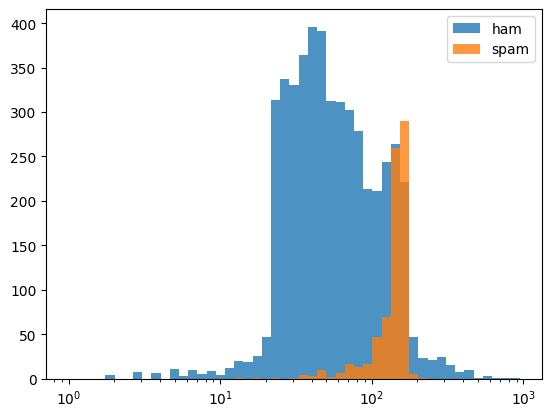

In [16]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.xscale('log')
bins = 1.15**(np.arange(0,50))
plt.hist(df[df['label']=='ham']['length'],bins=bins,alpha=0.8,label="ham")
plt.hist(df[df['label']=='spam']['length'],bins=bins,alpha=0.8,label="spam")
# plt.legend(('ham','spam'))
plt.legend()
plt.show()

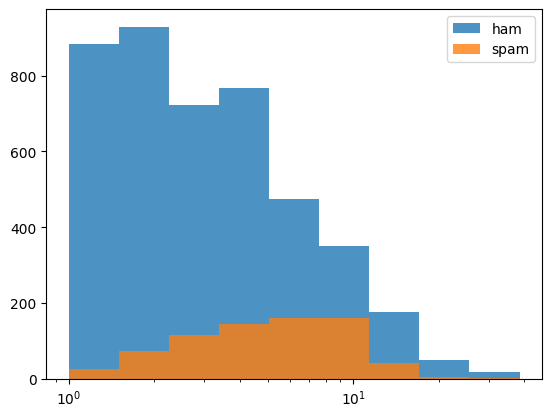

In [19]:
plt.xscale('log')
bins = 1.5**(np.arange(0,10))
plt.hist(df[df['label']=='ham']['punct'],bins=bins,alpha=0.8)
plt.hist(df[df['label']=='spam']['punct'],bins=bins,alpha=0.8)
plt.legend(('ham','spam'))
plt.show()

In [20]:
X = df[['length','punct']]
y = df['label']

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

print('Training Data Shape:', X_train.shape)
print('Testing Data Shape: ', X_test.shape)
print('Training Data Shape:', y_train.shape)
print('Testing Data Shape: ', y_test.shape)

Training Data Shape: (3733, 2)
Testing Data Shape:  (1839, 2)
Training Data Shape: (3733,)
Testing Data Shape:  (1839,)


In [22]:
y_train.value_counts()

,count
label,
ham,3232
spam,501


In [23]:
y_test.value_counts()

,count
label,
ham,1593
spam,246


In [24]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(solver='lbfgs')

lr_model.fit(X_train, y_train)

LogisticRegression()

In [ ]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

predictions = lr_model.predict(X_test)
acc_score = accuracy_score(y_test,predictions)
print(acc_score)
print(confusion_matrix(y_test,predictions))
print(classification_report(y_test,predictions))

[[1547   46]
 [ 241    5]]
              precision    recall  f1-score   support

         ham       0.87      0.97      0.92      1593
        spam       0.10      0.02      0.03       246

    accuracy                           0.84      1839
   macro avg       0.48      0.50      0.47      1839
weighted avg       0.76      0.84      0.80      1839

0.843936922240348


In [28]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

texts = [
    "free money",
    "win prize",
    "hello friend",
    "how are you"
]

labels = [
    "spam",
    "spam",
    "ham",
    "ham"
]

vectorizer = CountVectorizer()

X = vectorizer.fit_transform(texts)

model = MultinomialNB(
    alpha=1.0,
    fit_prior=True,
    class_prior=None
)

model.fit(X, labels)

new = vectorizer.transform(["free prize"])

prediction = model.predict(new)

print(prediction)


['spam']


In [33]:
from sklearn.naive_bayes import MultinomialNB
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
predictions = nb_model.predict(X_test)
acc_score = accuracy_score(y_test,predictions)
print(acc_score)
print(confusion_matrix(y_test,predictions))
print(classification_report(y_test,predictions))

0.8607939097335509
[[1583   10]
 [ 246    0]]
              precision    recall  f1-score   support

         ham       0.87      0.99      0.93      1593
        spam       0.00      0.00      0.00       246

    accuracy                           0.86      1839
   macro avg       0.43      0.50      0.46      1839
weighted avg       0.75      0.86      0.80      1839



In [31]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.svm import SVC
svc_model = SVC(gamma='auto')
svc_model.fit(X_train,y_train)

predictions = svc_model.predict(X_test)
acc_score = accuracy_score(y_test,predictions)
print(acc_score)
print(confusion_matrix(y_test,predictions))
print(classification_report(y_test,predictions))

0.8863512778684067
[[1515   78]
 [ 131  115]]
              precision    recall  f1-score   support

         ham       0.92      0.95      0.94      1593
        spam       0.60      0.47      0.52       246

    accuracy                           0.89      1839
   macro avg       0.76      0.71      0.73      1839
weighted avg       0.88      0.89      0.88      1839



In [36]:
df['message'].value_counts()

,count
message,
"Sorry, I'll call later",30
I cant pick the phone right now. Pls send a message,12
Ok...,10
Ok,4
Please call our customer service representative on FREEPHONE 0808 145 4742 between 9am-11pm as you have WON a guaranteed £1000 cash or £5000 prize!,4
...,...
I think asking for a gym is the excuse for lazy people. I jog.,1
I love your ass! Do you enjoy doggy style? :),1
"Come to me, slave. Your doing it again ... Going into your shell and unconsciously avoiding me ... You are making me unhappy :-(",1


In [35]:
from sklearn.model_selection import train_test_split

X = df['message']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [37]:
y_train.value_counts()

,count
label,
ham,3232
spam,501


In [38]:
y_test.value_counts()

,count
label,
ham,1593
spam,246


In [69]:
from sklearn.feature_extraction.text import CountVectorizer
count_vect = CountVectorizer()
from sklearn.svm import SVC

X_train_counts = count_vect.fit_transform(X_train)
X_test_counts = count_vect.transform(X_test)
X_train_counts.shape
model=SVC(kernel='linear')
model.fit(X_train_counts,y_train)
predictions = model.predict(X_test_counts)
acc_score = accuracy_score(y_test,predictions)
print(acc_score)
print(confusion_matrix(y_test,predictions))
print(classification_report(y_test,predictions))

0.9885807504078303
[[1592    1]
 [  20  226]]
              precision    recall  f1-score   support

         ham       0.99      1.00      0.99      1593
        spam       1.00      0.92      0.96       246

    accuracy                           0.99      1839
   macro avg       0.99      0.96      0.97      1839
weighted avg       0.99      0.99      0.99      1839



In [64]:
from sklearn.feature_extraction.text import TfidfTransformer
tfidf_transformer = TfidfTransformer()

X_train_tfidf = tfidf_transformer.fit_transform(X_train_counts)
X_train_tfidf.shape

(3733, 7082)

In [66]:
df_sparse = pd.DataFrame.sparse.from_spmatrix(
    X_train_tfidf,
    columns=tfidf_transformer.get_feature_names_out()
)
df_sparse.head()

,x0,x1,x2,x3,x4,x5,x6,x7,x8,x9,...,x7072,x7073,x7074,x7075,x7076,x7077,x7078,x7079,x7080,x7081
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [67]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

docs = [
    "I love AI",
    "AI changes the world",
    "Machine learning is fun"
]

tfidf = TfidfVectorizer()

X = tfidf.fit_transform(docs)

df = pd.DataFrame.sparse.from_spmatrix(
    X,
    columns=tfidf.get_feature_names_out()
)

print(df)

         ai   changes  fun   is  learning      love  machine       the  \
0  0.605349         0    0    0         0  0.795961        0         0   
1   0.40204  0.528635    0    0         0         0        0  0.528635   
2         0         0  0.5  0.5       0.5         0      0.5         0   

      world  
0         0  
1  0.528635  
2         0  


In [59]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words=None,
    max_features=None,
    ngram_range=(1,1),
    min_df=1,
    max_df=1.0
)

X_train_tfidf = vectorizer.fit_transform(X_train) # remember to use the original X_train set
X_train_tfidf.shape
print(X_train_tfidf.toarray())
print(vectorizer.vocabulary_)
print(vectorizer.get_feature_names_out())

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
{'yup': 7069, 'not': 4415, 'comin': 1736, 'sent': 5512, 'my': 4270, 'scores': 5443, 'to': 6330, 'sophas': 5791, 'and': 878, 'had': 3008, 'do': 2156, 'secondary': 5468, 'application': 935, 'for': 2677, 'few': 2566, 'schools': 5437, 'think': 6247, 'if': 3280, 'you': 7048, 'are': 957, 'thinking': 6250, 'of': 4470, 'applying': 938, 'research': 5243, 'on': 4513, 'cost': 1835, 'also': 849, 'contact': 1797, 'joke': 3501, 'ogunrinde': 4489, 'her': 3116, 'school': 5436, 'is': 3416, 'one': 4518, 'me': 4018, 'the': 6219, 'less': 3726, 'expensive': 2472, 'ones': 4519, 'kothi': 3621, 'print': 4959, 'out': 4583, 'marandratha': 3966, 'its': 3436, 'just': 3532, 'effect': 2310, 'irritation': 3414, 'ignore': 3283, 'it': 3428, 'asked': 996, 'call': 1454, 'him': 3133, 'now': 4426, 'ok': 4494, 'whatever': 6828, 'juliana': 3524, 'want': 6744, 'hello': 31

In [60]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC

pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        stop_words="english",
        max_features=5000,
        ngram_range=(1,2)
    )),
    ("classifier", SVC(kernel="linear"))
])

pipeline.fit(X_train, y_train)

predictions = pipeline.predict(X_test)
acc_score = accuracy_score(y_test,predictions)
print(acc_score)
print(confusion_matrix(y_test,predictions))
print(classification_report(y_test,predictions))

0.9874932028276238
[[1588    5]
 [  18  228]]
              precision    recall  f1-score   support

         ham       0.99      1.00      0.99      1593
        spam       0.98      0.93      0.95       246

    accuracy                           0.99      1839
   macro avg       0.98      0.96      0.97      1839
weighted avg       0.99      0.99      0.99      1839



In [42]:
from sklearn.svm import LinearSVC
clf = LinearSVC()
clf.fit(X_train_tfidf,y_train)

LinearSVC()

In [44]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC

vectorizer = TfidfVectorizer()

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

model = SVC(kernel="linear")

model.fit(X_train_vec, y_train)

pred = model.predict(X_test_vec)
acc_score = accuracy_score(y_test,pred)
print(acc_score)
print(confusion_matrix(y_test,pred))
print(classification_report(y_test,pred))

0.9923871669385536
[[1590    3]
 [  11  235]]
              precision    recall  f1-score   support

         ham       0.99      1.00      1.00      1593
        spam       0.99      0.96      0.97       246

    accuracy                           0.99      1839
   macro avg       0.99      0.98      0.98      1839
weighted avg       0.99      0.99      0.99      1839



In [49]:
texts = [
    "I love AI",
    "Win free money",
    "Hello friend",
    "Claim your prize"
]

labels = [
    "ham",
    "spam",
    "ham",
    "spam"
]
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC

pipeline = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("classifier", SVC(kernel="linear"))
])
pipeline.fit(texts, labels)
pipeline.predict(["Free prize"])

array(['spam'], dtype='<U4')

In [43]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

text_clf = Pipeline([('tfidf', TfidfVectorizer()),
                     ('clf', LinearSVC()),])


text_clf.fit(X_train, y_train)


predictions = text_clf.predict(X_test)

In [54]:
from sklearn.metrics import confusion_matrix,classification_report

acc_score = accuracy_score(y_test,predictions)
print(acc_score)
print(confusion_matrix(y_test,predictions))
print(classification_report(y_test,predictions))

0.989668297988037
[[1586    7]
 [  12  234]]
              precision    recall  f1-score   support

         ham       0.99      1.00      0.99      1593
        spam       0.97      0.95      0.96       246

    accuracy                           0.99      1839
   macro avg       0.98      0.97      0.98      1839
weighted avg       0.99      0.99      0.99      1839



In [ ]:
print(metrics.classification_report(y_test,predictions))

              precision    recall  f1-score   support

         ham       0.99      1.00      0.99      1593
        spam       0.97      0.95      0.96       246

    accuracy                           0.99      1839
   macro avg       0.98      0.97      0.98      1839
weighted avg       0.99      0.99      0.99      1839



In [ ]:
print(metrics.accuracy_score(y_test,predictions))

0.989668297988037


In [51]:
text_clf.predict(['Hi How are you ? '])[0]

'ham'

In [52]:
text_clf.predict(['Congratulations , you won @ rolex '])[0]

'spam'

In [53]:
text_clf.predict(['I need to meet you tomorrow at office congratulation !! , you can have your prize now @@ '])[0]

'ham'